# KSB — Per-input kinematics vs position

Plots velocity, acceleration, and jerk for each input with **position** on the x-axis.
Time samples are uniform; the resulting position samples are heterogeneous — that is fine.
Shading marks buffer sub-segments (fixed position boundaries) and the registrar zone.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from ksb.simulation.ksb_simulation import KSBSimulation
from ksb.simulation.result import SimulationResult
from ksb.planning.solvers.scurve import SCurveSolver
from ksb.motion.trajectories import CompositeTrajectory, P, V, A
from ksb.visualization.input_plots import _eval_jerk

import yaml
from pathlib import Path

with open(Path('..') / 'configs' / 'system' / 'default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg

{'batch': 100,
 'input_length': 0.32,
 'input_gap_mean': 0.6,
 'input_gap_std': 0.05,
 'input_gap_rho': 1.0,
 'arrival_rate_ppm': 150,
 'upstream_control': 'constant',
 'L_upstream': 2.0,
 'j_u_max': 100.0,
 'v_u_max': 3.5,
 'a_u_max': 0.05,
 'jmax': 100.0,
 'Vmax': 3.5,
 'Amax': 8.5,
 'beta': 0.0,
 'gamma': 0.0,
 'solver': 'quintic',
 'L_buffer': 2.5,
 'n_buffer_seg': 7,
 'eta_v': 1.0,
 'v_min': 0.0,
 'start_margin': 1,
 'end_margin': 0.0,
 'L_registrar': 1.5,
 'n_reg_seg': 1,
 'L_downstream': 2.0,
 'eta_s': 2.0,
 'eta_r': 1.0,
 'a_max_sync': 25.0,
 'j_max_sync': 300}

In [2]:
sim = KSBSimulation(cfg=cfg)
result = sim.run(seed=42, skip_pair_records=True)
print(result.skip_indices)

[]


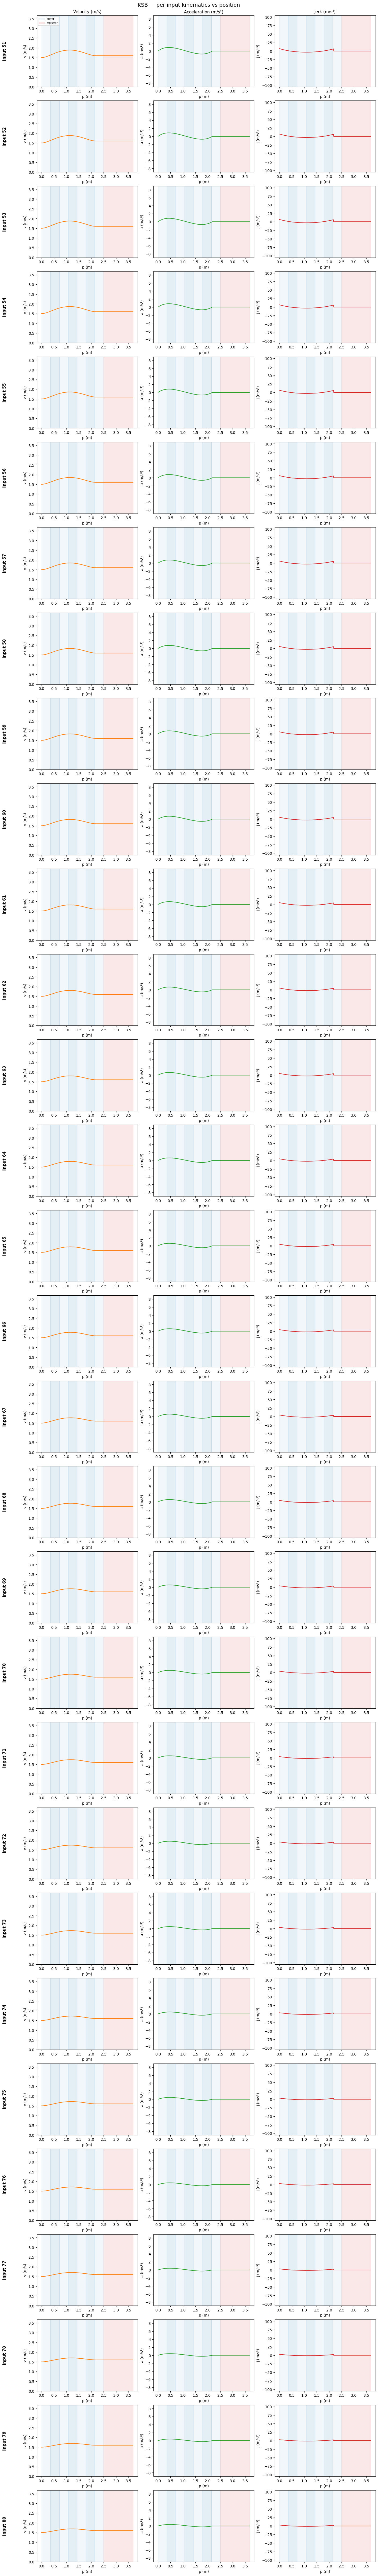

In [3]:
N        = 30
i_start  = 50
n_samples = 500

Vmax        = float(cfg.get('Vmax', 3.0))
Amax        = float(cfg.get('Amax', 8.5))
jmax        = float(cfg.get('jmax', 100.0))
L_buffer    = float(cfg.get('L_buffer', 2.0))
n_buffer_seg = int(cfg.get('n_buffer_seg', 5))

buffer_boundaries = np.linspace(0.0, L_buffer, n_buffer_seg + 1)
alphas = [0.06, 0.12]

COL_LABELS = ['Velocity (m/s)', 'Acceleration (m/s²)', 'Jerk (m/s³)']

fig, axes = plt.subplots(
    N, 3,
    figsize=(14, 3.2 * N),
    squeeze=False,
    constrained_layout=True,
)
fig.suptitle('KSB — per-input kinematics vs position', fontsize=14)

for col, label in enumerate(COL_LABELS):
    axes[0, col].set_title(label, fontsize=11)

for i in range(N):
    segs = result.system_trajectories[i + i_start].segments
    buff_traj     = segs[1]
    straddle_traj = segs[2]
    reg_traj      = segs[3]

    combined_traj = CompositeTrajectory(
        x0=buff_traj.x0,
        T=buff_traj.T + straddle_traj.T + reg_traj.T,
        segments=(buff_traj, straddle_traj, reg_traj),
    )

    t      = np.linspace(0.0, combined_traj.T, n_samples)
    states = combined_traj.eval(t)   # shape (3, n_samples)
    pos    = states[P]               # x-axis values (heterogeneous spacing — that's fine)

    # Position at registrar start (fixed reference for shading)
    t_reg_start = buff_traj.T + straddle_traj.T
    p_reg_start = combined_traj.eval(np.array([t_reg_start]))[P, 0]
    p_end       = pos[-1]

    jerk = _eval_jerk(combined_traj, t)

    def _shade(ax, first_row=False):
        for j in range(len(buffer_boundaries) - 1):
            ax.axvspan(
                buffer_boundaries[j], buffer_boundaries[j + 1],
                alpha=alphas[j % 2], color='C0', zorder=-1,
                label='buffer' if (j == 0 and first_row) else '',
            )
        ax.axvspan(
            p_reg_start, p_end,
            alpha=0.10, color='C3', zorder=-1,
            label='registrar' if first_row else '',
        )

    axes[i, 0].annotate(
        f'Input {i + i_start + 1}',
        xy=(-0.32, 0.5), xycoords='axes fraction',
        ha='center', va='center', fontsize=11, fontweight='bold', rotation=90,
    )

    # col 0 — velocity
    axes[i, 0].plot(pos, states[V], color='C1')
    _shade(axes[i, 0], first_row=(i == 0))
    axes[i, 0].set_xlabel('p (m)')
    axes[i, 0].set_ylabel('v (m/s)')
    axes[i, 0].set_ylim(0, 1.05*Vmax)

    # col 1 — acceleration
    axes[i, 1].plot(pos, states[A], color='C2')
    _shade(axes[i, 1])
    axes[i, 1].set_xlabel('p (m)')
    axes[i, 1].set_ylabel('a (m/s²)')
    axes[i, 1].set_ylim(-1.05*Amax, 1.05*Amax)

    # col 2 — jerk
    if jerk is not None:
        axes[i, 2].plot(pos, jerk, color='C3')
        _shade(axes[i, 2])
        axes[i, 2].set_xlabel('p (m)')
        axes[i, 2].set_ylabel('j (m/s³)')
        axes[i, 2].set_ylim(-jmax * 1.05, jmax * 1.05)
    else:
        axes[i, 2].axis('off')
        axes[i, 2].text(
            0.5, 0.5,
            'Jerk not available\n(segment type has no\nanalytical jerk method)',
            ha='center', va='center',
            transform=axes[i, 2].transAxes,
            fontsize=9, color='gray',
        )

    if i == 0:
        axes[i, 0].legend(fontsize=7, loc='upper left')

plt.show()